In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
X_train = pd.read_csv('X_train_ohe_int.csv')
X_test = pd.read_csv('X_test_ohe_int.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

In [3]:
# ===== 1) Model baseline Random Forest =====
rf = RandomForestClassifier(
    # Jumlah pohon (trees) yang dibangun dalam ensemble
    # Default = 100, makin banyak pohon → prediksi lebih stabil tapi waktu training lebih lama
    n_estimators=100,

    # Fungsi impurity untuk tiap tree (gini atau entropy/log_loss)
    criterion="gini",

    # Membatasi kedalaman pohon (None = pohon tumbuh penuh)
    max_depth=None,

    # Jumlah fitur yang dipakai saat mencari split terbaik (default: 'sqrt' untuk klasifikasi)
    max_features="sqrt",

    # Class weight untuk menangani imbalance
    class_weight="balanced",

    # Random seed agar hasil reproducible
    random_state=42,

    # Gunakan semua core CPU untuk mempercepat training
    n_jobs=-1
)

In [4]:
# ===== 2) Training model =====
rf.fit(X_train, y_train.ravel())

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [5]:
# ===== 3) Prediksi =====
y_pred = rf.predict(X_test)


In [6]:
# ===== 4) Evaluasi =====
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[853 180]
 [174 200]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83      1033
           1       0.53      0.53      0.53       374

    accuracy                           0.75      1407
   macro avg       0.68      0.68      0.68      1407
weighted avg       0.75      0.75      0.75      1407



In [7]:
# Hitung ROC-AUC
y_proba = rf.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7782249923642782


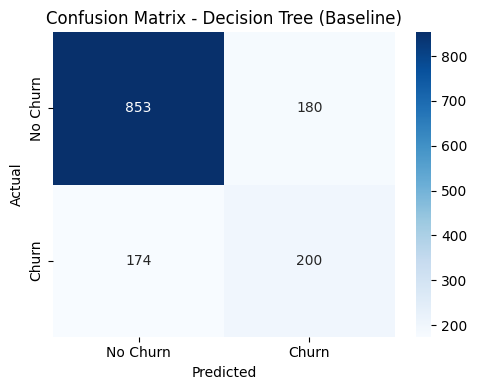

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=['No Churn', 'Churn'],  # kolom = Prediksi
    yticklabels=['No Churn', 'Churn']   # baris  = Aktual
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree (Baseline)")
plt.tight_layout()
plt.show()